In [77]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/
import functions as fn

%load_ext autoreload
%autoreload 2

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### Load data

In [7]:
ws_dict = {}
for data_name in ["ERA5", "BARRA-R2"]:
    if data_name == "ERA5":
        var_name = "ws10m"
    else:
        var_name = "wss"
    
    for grid in ["NEM", "SWIS", "NWIS"]:
        
        if grid == "NEM":
            
            for scenario in ["wind_2025", "wind_2030", "wind_2040", "wind_2050"]:
                
                for subgrid in ["NEM", "SE"]:
                    
                    for unweight in [True, False]:
                        
                        fname = "grid_mean_"+var_name+"_"+data_name+"_"+grid+"_"+scenario+"_"+subgrid+"_"
                        key = data_name+"_"+grid+"_"+subgrid+"_"+scenario+"_"
                        
                        if unweight:
                            fname = fname+"unweighted"
                            key = key+"unweighted"
                        else:
                            fname = fname+"weighted"
                            key = key+"weighted"

                        
                        ws_dict[key] = xr.open_dataarray(FILEPATH+fname+".nc")
        else:
            name = "grid_mean_"+var_name+"_"+data_name+"_"+grid
            key = data_name+"_"+grid
            ws_dict[key] = xr.open_dataarray(FILEPATH+fname+".nc")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [14]:
# Check size
nbytes = []
for k, v in ws_dict.items():
    nbytes.append(v.nbytes)
sum(nbytes) / 1024 ** 3

0.00450664758682251

### Wind speed statistics

In [16]:
da = ws_dict["ERA5_NEM_NEM_wind_2025_unweighted"]

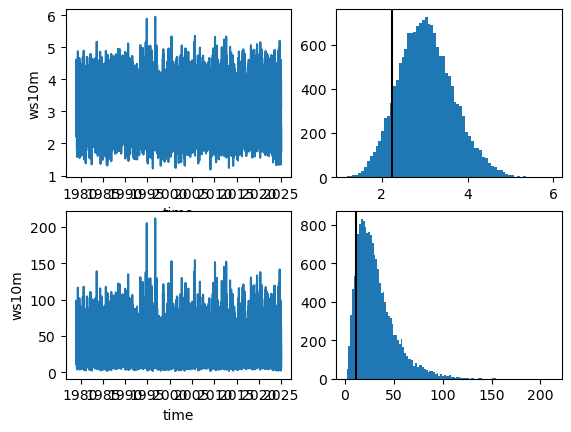

In [37]:
fig, ax = plt.subplots(2, 2)

da.plot(ax=ax[0,0])
_ = ax[0,1].hist(da, "fd")
ax[0,1].axvline(da.quantile(0.1, "time"), c="k")

# da.resample(time="1YS").mean().plot(ax=ax[1,0])
# _ = ax[1,1].hist(da.resample(time="1YS").mean(), "fd")

(da ** 3).plot(ax=ax[1,0])
_ = ax[1,1].hist((da ** 3), "fd")
ax[1,1].axvline((da ** 3).quantile(0.1, "time"), c="k")

### Drought definition

10th percentile, based on AEMO report for wind lulls (pg 31, Fig 41): https://www.aemo.com.au/-/media/files/major-publications/qed/2025/qed-q3-2025.pdf?rev=7436be91333e4603bc59158b0bf095a1&sc_lang=en&hash=A49B4BC337B25B842566B8F5EE4C8331 

In [84]:
def cumsum_reset(da, dim="time"):
    """
    Return array of drought run lengths
    
    da: binary array
    """
    # Work with numpy array
    arr = da.values
    # Find where resets (zeros) occur
    reset = (arr == 0)
    # Create same-shape output
    out = np.zeros_like(arr, dtype=int)
    
    # Iterate along the chosen dimension
    axis = da.get_axis_num(dim)
    # Move the dim to the front for easier iteration
    arr = np.moveaxis(arr, axis, 0)
    reset = np.moveaxis(reset, axis, 0)
    out = np.moveaxis(out, axis, 0)
    
    # Iterate along the chosen dimension
    acc = np.zeros_like(arr[0], dtype=float)
    for i in range(arr.shape[0]):
        acc = np.where(reset[i], 0, acc + arr[i])
        out[i] = acc

    # Move back to original axis order
    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=da.coords, dims=da.dims, attrs=da.attrs)

In [112]:
def cumsum_reset_on_mask(data, mask, dim="time"):
    """
    Cumulative sum of `data` along `dim`, resetting to zero wherever `mask` == 0.
    
    Parameters
    ----------
    data : xr.DataArray
        Array to accumulate.
    mask : xr.DataArray
        Binary array of the same shape, where 0 means "reset".
    dim : str
        Dimension along which to accumulate (default: "time").
        
    Returns
    -------
    xr.DataArray
        Same shape as `data`, cumulative sum with resets.
    """
    a = data.values
    reset = (mask.values == 0)

    out = np.zeros_like(a, dtype=float)

    axis = data.get_axis_num(dim)
    a = np.moveaxis(a, axis, 0)
    reset = np.moveaxis(reset, axis, 0)
    out = np.moveaxis(out, axis, 0)

    acc = np.zeros_like(a[0], dtype=float)
    for i in range(a.shape[0]):
        acc = np.where(reset[i], 0, acc + a[i])
        out[i] = acc

    out = np.moveaxis(out, 0, axis)
    return xr.DataArray(out, coords=data.coords, dims=data.dims, attrs=data.attrs)


In [85]:
DROUGHT_Q = 0.1

In [120]:
for k,v in ws_dict.items():
    ds = v.to_dataset(name=v.name)

    # Compute drought days and cumulative lengths
    drought_days = xr.where(v < v.quantile(DROUGHT_Q, "time"), 1, 0)
    drought_sum = cumsum_reset_on_mask(drought_days, drought_days).astype("int")

    # Accumulate wind speed anomalies over drought days
    ws_clim = v.mean("time")
    ws_anoms = v - ws_clim
    ws_severity = cumsum_reset_on_mask(ws_anoms, drought_days)
    
    ds["drought_len_p"+str(int(DROUGHT_Q*100))] = drought_sum
    ds["drought_severity_p"+str(int(DROUGHT_Q*100))] = ws_severity

### Drought metrics

Number of drought days per year

In [88]:
def n_drought_days(da):
    """
    Return number of drought days per year
    """
    # return da.resample(time="1YS").sum()
    return xr.where(da > 0, 1, 0).resample(time="1YS").sum()

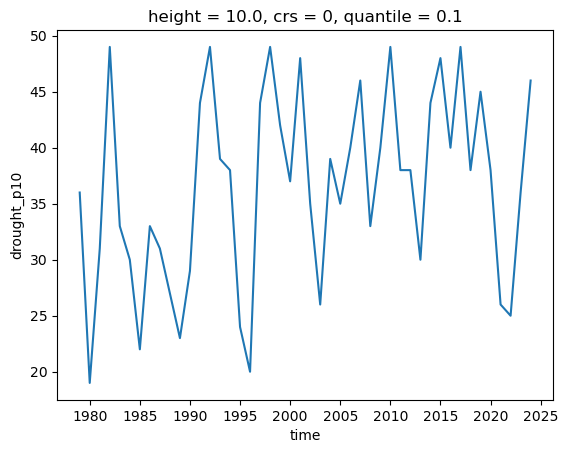

In [92]:
n_drought_days(ds["drought_p10"]).plot()

Number of drought periods per year

In [143]:
def n_droughts(da, min_len=1):
    """
    Return number of droughts of a minimum length per year
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(da >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return xr.where(diff == -1, 1, 0).resample(time="1YS").sum()

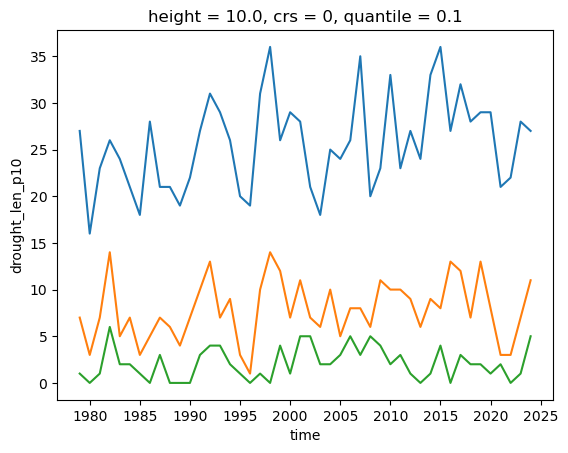

In [144]:
n_droughts(ds["drought_len_p10"], 1).plot()
n_droughts(ds["drought_len_p10"], 2).plot()
n_droughts(ds["drought_len_p10"], 3).plot()

Longest drought per year

In [93]:
def longest_drought(da):
    """
    Return longest drought each year
    """
    return da.groupby("time.year").max()

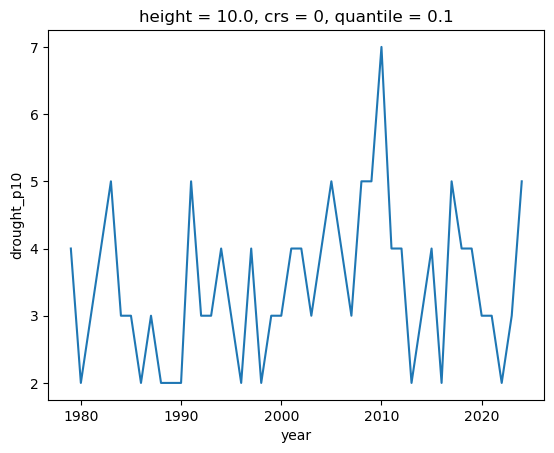

In [94]:
longest_drought(ds["drought_p10"]).plot()

Accumulated drought intensity

In [141]:
def max_intensity(da, mask, min_len=1):
    """
    Return annual max of drought intensity

    da: array of accumulated wind speed anomalies on drought days
    mask: array of drought periods
    min_len: int, minimum number of consecutive drought days per drought period
    """
    # Set drought days that occur in drought periods as 1, else 0
    binary = xr.where(mask >= min_len, 1, 0)
    # Find days that are end of droughts (this enables cross-year droughts counted in end year)
    diff = binary.diff("time").shift(time=-1)
    # Count these days per year
    return da.where(diff == -1).resample(time="1YS").min()

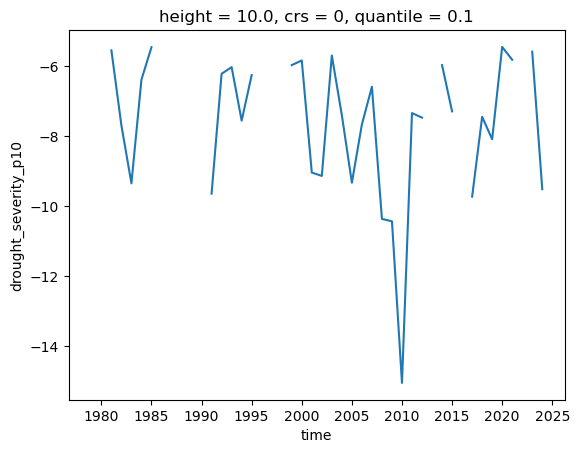

In [147]:
max_intensity(ds["drought_severity_p10"], ds["drought_len_p10"], min_len=3).plot()

In [150]:
ds["drought_len_p10"].where(ds["drought_len_p10"] == 7).dropna("time")

<xarray.DataArray 'drought_len_p10' (time: 1)> Size: 8B
array([7.])
Coordinates:
  * time      (time) datetime64[ns] 8B 2010-05-21
    height    float64 8B 10.0
    crs       int32 4B 0
    quantile  float64 8B 0.1

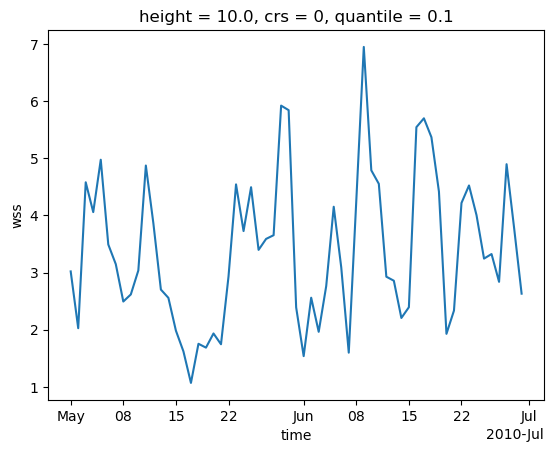

In [152]:
ds["wss"].sel(time=slice("2010-05", "2010-06")).plot()

In [130]:
ds["drought_severity_p10"].resample(time="1YS").min()

<xarray.DataArray 'drought_severity_p10' (time: 46)> Size: 368B
array([ -7.95469732,  -4.80728588,  -5.55155783,  -7.69611977,
        -9.34914191,  -6.3882153 ,  -5.46232254,  -4.29285357,
        -6.48326159,  -3.98631461,  -4.01618001,  -3.91342145,
        -9.64492227,  -6.22092682,  -6.0311143 ,  -7.55924151,
        -6.25922227,  -3.07617977,  -8.02139236,  -4.28077206,
        -5.97379646,  -5.84071721,  -9.04176744,  -9.1377623 ,
        -5.69956926,  -7.40278144,  -9.33013506,  -7.66783193,
        -6.59173296, -10.36528634, -10.43390948, -15.04836883,
        -7.34325368,  -7.47197979,  -4.16524484,  -5.97185003,
        -7.29501982,  -3.92927764,  -9.73005693,  -7.45024793,
        -8.09026407,  -5.45402073,  -5.82086627,  -4.12466461,
        -5.59071176,  -9.51478984])
Coordinates:
  * time      (time) datetime64[ns] 368B 1979-01-01 1980-01-01 ... 2024-01-01
    height    float64 8B ...
    crs       int32 4B ...
    quantile  float64 8B 0.1